# AV1 (CR residual): Residual Structure Comparison

This notebook checks whether newer models reduce the structured residual patterns identified after the Chapman-Richards baseline. It is deliberately read-only: it loads existing predictions and data, displays diagnostics, and does not write figures or modify model code.

Core question: if the statistical/spatial analysis found structure in Chapman-Richards residuals, do the DNN/PINN residuals still contain the same structure?

> Scope note (2026-08-04): This notebook diagnoses residual structure for the **AV1 / Stage 1-style target family** and compares models on that older avenue. It is still valid, but it does not answer the newer **AV2 per-plot growth-curve vs. yldc** question.

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "outputs").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root containing outputs/ and data/.")

ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
ROOT

PosixPath('/Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss')

## Configuration

Start with the primary dissertation cell: `4survey` + `spatial_block`. Change `COHORT` and `SPLIT_TYPE` below if you want to repeat the same diagnostics for `6survey`, `temporal`, or `temporal_narrow_gap`.

In [2]:
COHORT = "4survey"
SPLIT_TYPE = "spatial_block_kfold"  # pooled 5-fold whole-population residuals, not one ~20% slice
N_FOLDS = 5
BASELINE_MODEL_DIRS = {"chapman_richards", "linear_baseline", "rf_baseline", "average_by_age"}

# Core models used in most residual-structure plots.
MODEL_RUNS = {
    "CR": "chapman_richards",
    "DNN no-env": "dnn_noenv",
    "PINN no-env w1": "pinn_noenv",
    "DNN env-terrain": "dnn_env_terrain",
    "PINN env-terrain": "pinn_env_terrain",
    "PINN env-terrain k": "pinn_env_terrain_k",
    "Linear": "linear_baseline",
    "RF": "rf_baseline",
    "Average by age": "average_by_age",
}

# Extra experiments are included in the broad metrics table if their output folders exist.
# They are not included in every residual plot by default, because too many lines obscure the main diagnostics.
EXTRA_MODEL_RUNS = {
    "DNN env-terrain extended": "dnn_env_terrain_extended",
    "PINN env w0/0": "pinn_env_terrain_w0_0",
    "PINN env w0.01/0": "pinn_env_terrain_w001_0",
    "PINN env w0.1/0": "pinn_env_terrain_w01_0",
    "PINN env w1/0": "pinn_env_terrain_w1_0",
    "PINN env extended w0/0": "pinn_env_terrain_extended_w0_0",
    "PINN env extended w1/0": "pinn_env_terrain_extended_w1_0",
    "Env-deviation CR": "env_deviation_cr",
    "Env-deviation DNN no-env": "env_deviation_dnn_noenv",
}

CORE_MODELS = ["CR", "DNN no-env", "PINN no-env w1", "DNN env-terrain", "PINN env-terrain", "PINN env-terrain k"]
TEST_ONLY = True

print(f"Diagnostics for {COHORT}, {SPLIT_TYPE} (pooled across {N_FOLDS} folds)")


Diagnostics for 4survey, spatial_block_kfold (pooled across 5 folds)


In [3]:
def prediction_path(model_dir, cohort=COHORT, split_type=SPLIT_TYPE):
    return ROOT / "outputs" / split_type / model_dir / cohort / "predictions.csv"

def kfold_prediction_paths(model_dir, cohort=COHORT, n_folds=N_FOLDS):
    # Baselines store each fold under a fold-suffixed TOP-LEVEL directory
    # (chapman_richards_fold0, ...); DNN/PINN store each fold under a
    # fold_<i> SUBdirectory of the plain model directory -- two different
    # conventions on disk, so both are handled here rather than forcing one.
    if model_dir in BASELINE_MODEL_DIRS:
        return [ROOT / "outputs" / "spatial_block_kfold" / f"{model_dir}_fold{i}" / cohort / "predictions.csv" for i in range(n_folds)]
    return [ROOT / "outputs" / "spatial_block_kfold" / model_dir / cohort / f"fold_{i}" / "predictions.csv" for i in range(n_folds)]

def load_predictions(model_label, model_dir, model_group="core"):
    if SPLIT_TYPE == "spatial_block_kfold":
        fold_frames = []
        for fold_index, path in enumerate(kfold_prediction_paths(model_dir)):
            if not path.exists():
                warnings.warn(f"Missing fold {fold_index} predictions for {model_label}: {path}")
                continue
            fold_df = pd.read_csv(path)
            fold_df["fold"] = fold_index
            fold_frames.append(fold_df)
        if not fold_frames:
            warnings.warn(f"No folds found at all for {model_label}")
            return None
        df = pd.concat(fold_frames, ignore_index=True)
    else:
        path = prediction_path(model_dir)
        if not path.exists():
            warnings.warn(f"Missing predictions for {model_label}: {path}")
            return None
        df = pd.read_csv(path)
    if TEST_ONLY and "split" in df.columns:
        df = df[df["split"] == "test"].copy()
    required = {"identification", "LiDAR_year", "Age", "observed_top_height", "predicted_top_height", "residual"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{model_label} is missing columns: {sorted(missing)}")
    df["model"] = model_label
    df["model_dir"] = model_dir
    df["model_group"] = model_group
    return df

prediction_frames = []
for label, model_dir in MODEL_RUNS.items():
    loaded = load_predictions(label, model_dir, model_group="core")
    if loaded is not None:
        prediction_frames.append(loaded)
for label, model_dir in EXTRA_MODEL_RUNS.items():
    loaded = load_predictions(label, model_dir, model_group="extra")
    if loaded is not None:
        prediction_frames.append(loaded)

predictions = pd.concat(prediction_frames, ignore_index=True)
print(predictions.shape)
print("Loaded models:", ", ".join(predictions["model"].drop_duplicates()))
predictions.head()


/var/folders/x0/2y372y254qxd8j967dgmwpr00000gn/T/ipykernel_99101/2961181684.py:18: UserWarning: Missing fold 0 predictions for DNN env-terrain extended: /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/outputs/spatial_block_kfold/dnn_env_terrain_extended/4survey/fold_0/predictions.csv
  warnings.warn(f"Missing fold {fold_index} predictions for {model_label}: {path}")
/var/folders/x0/2y372y254qxd8j967dgmwpr00000gn/T/ipykernel_99101/2961181684.py:18: UserWarning: Missing fold 1 predictions for DNN env-terrain extended: /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/outputs/spatial_block_kfold/dnn_env_terrain_extended/4survey/fold_1/predictions.csv
  warnings.warn(f"Missing fold {fold_index} predictions for {model_label}: {path}")
/var/folders/x0/2y372y254qxd8j967dgmwpr00000gn/T/ipykernel_99101/2961181684.py:18: UserWarning: Missing fold 2 predictions for DNN env-terrain extended: /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/outputs/spatial_block_kfold/dnn_env_t

(2091564, 15)


Loaded models: CR, DNN no-env, PINN no-env w1, DNN env-terrain, PINN env-terrain, PINN env-terrain k, Linear, RF, Average by age


,identification,blk,cpmt,LiDAR_year,Age,observed_top_height,predicted_top_height,residual,split,fold,model,model_dir,model_group,learned_y_max,learned_k
0,8897,30,2250,2008,71,27.440718,28.794677,-1.353959,test,0,CR,chapman_richards,core,NaN,NaN
1,8897,30,2250,2012,75,29.505350,29.753496,-0.248146,test,0,CR,chapman_richards,core,NaN,NaN
2,8897,30,2250,2021,84,32.268894,31.760890,0.508004,test,0,CR,chapman_richards,core,NaN,NaN
3,8897,30,2250,2023,86,32.107405,32.180516,-0.073111,test,0,CR,chapman_richards,core,NaN,NaN
4,8898,30,2250,2008,71,28.411161,28.794677,-0.383516,test,0,CR,chapman_richards,core,NaN,NaN


## Overall Prediction Metrics

This is the ordinary accuracy comparison. It does not yet answer whether the models removed the same residual structure as the statistical analysis, but it gives the baseline context.

In [4]:
def metrics_for_group(df):
    observed = df["observed_top_height"].to_numpy(dtype=float)
    predicted = df["predicted_top_height"].to_numpy(dtype=float)
    residual = observed - predicted
    sse = np.sum(residual ** 2)
    sst = np.sum((observed - observed.mean()) ** 2)
    return pd.Series({
        "n_rows": len(df),
        "n_plots": df["identification"].nunique(),
        "mae": np.mean(np.abs(residual)),
        "rmse": np.sqrt(np.mean(residual ** 2)),
        "r2": 1 - sse / sst,
        "bias": residual.mean(),
        "residual_sd": residual.std(ddof=1),
    })

metrics = predictions.groupby("model", sort=False).apply(metrics_for_group).sort_values("rmse")
metrics

,n_rows,n_plots,mae,rmse,r2,bias,residual_sd
model,,,,,,,
DNN env-terrain,232292.0,58073.0,3.504130,4.663223,0.662595,0.132480,4.661351
DNN no-env,232448.0,58112.0,3.749747,4.885046,0.629827,0.051923,4.884780
PINN env-terrain k,232292.0,58073.0,4.041874,5.205891,0.579496,0.080579,5.205279
PINN env-terrain,232292.0,58073.0,4.053537,5.211863,0.578531,0.037143,5.211742
PINN no-env w1,232448.0,58112.0,4.103837,5.243774,0.573464,0.104365,5.242747
Linear,232448.0,58112.0,4.333940,5.465796,0.536581,0.032049,5.465714
RF,232448.0,58112.0,4.411002,5.816507,0.475203,0.032209,5.816430
CR,232448.0,58112.0,5.030007,6.313735,0.381642,-0.008042,6.313743
Average by age,232448.0,58112.0,5.091807,6.427670,0.359123,-0.037254,6.427576


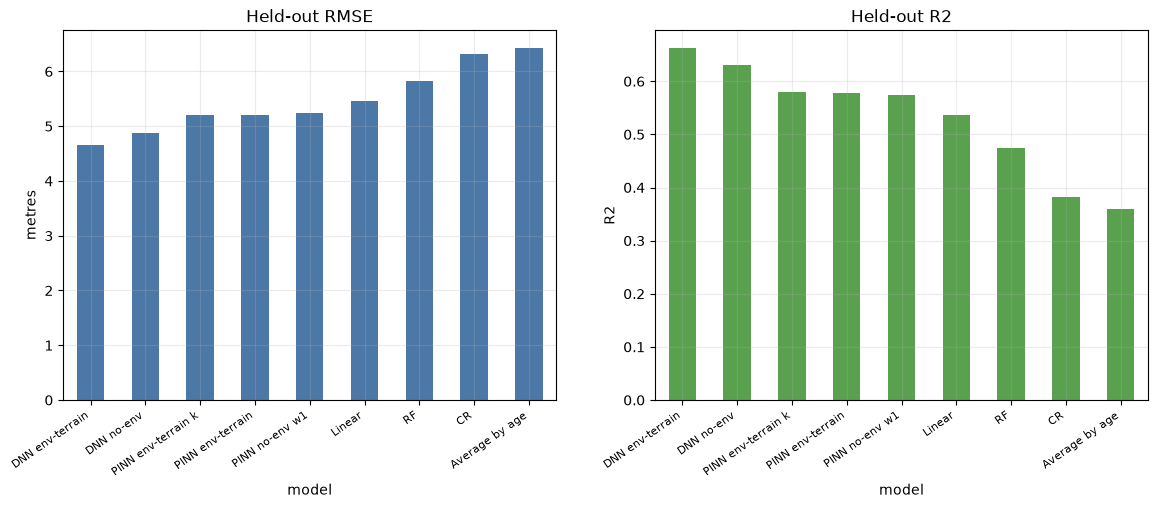

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
metrics["rmse"].sort_values().plot.bar(ax=axes[0], color="#4c78a8")
axes[0].set_title("Held-out RMSE")
axes[0].set_ylabel("metres")
metrics["r2"].sort_values(ascending=False).plot.bar(ax=axes[1], color="#59a14f")
axes[1].set_title("Held-out R2")
axes[1].set_ylabel("R2")
for ax in axes:
    ax.tick_params(axis="x", rotation=35, labelsize=8)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")


## Extra Experiment And Seed-Sensitivity Summary

This section includes newer output folders if they exist. It separates two questions:

1. Which individual run has the best held-out metrics?
2. Is an apparent improvement stable across split seeds, or is it dependent on which compartments happened to be held out?

In [6]:
extra_metrics = metrics.copy()
extra_metrics["model_group"] = predictions.groupby("model")["model_group"].first()
extra_metrics.sort_values("rmse")

,n_rows,n_plots,mae,rmse,r2,bias,residual_sd,model_group
model,,,,,,,,
DNN env-terrain,232292.0,58073.0,3.504130,4.663223,0.662595,0.132480,4.661351,core
DNN no-env,232448.0,58112.0,3.749747,4.885046,0.629827,0.051923,4.884780,core
PINN env-terrain k,232292.0,58073.0,4.041874,5.205891,0.579496,0.080579,5.205279,core
PINN env-terrain,232292.0,58073.0,4.053537,5.211863,0.578531,0.037143,5.211742,core
PINN no-env w1,232448.0,58112.0,4.103837,5.243774,0.573464,0.104365,5.242747,core
Linear,232448.0,58112.0,4.333940,5.465796,0.536581,0.032049,5.465714,core
RF,232448.0,58112.0,4.411002,5.816507,0.475203,0.032209,5.816430,core
CR,232448.0,58112.0,5.030007,6.313735,0.381642,-0.008042,6.313743,core
Average by age,232448.0,58112.0,5.091807,6.427670,0.359123,-0.037254,6.427576,core


In [7]:
import json

def load_kfold_summary(model_dir, cohort=COHORT):
    path = ROOT / "outputs" / "spatial_block_kfold" / model_dir / cohort / "kfold_summary.json"
    if not path.exists():
        return None
    with open(path) as f:
        return json.load(f)

def per_fold_delta_summary(noenv_dir, env_dir, cohort=COHORT):
    # Replaces the old paired SPLIT-SEED robustness check (2026-08-07): those "_splitseedN"
    # reruns only exist under single-split spatial_block, with no k-fold equivalent, so they
    # can't answer "is this robust" once the main analysis above is pooled 5-fold. The 5 real
    # folds ARE a genuine repeated-measures design already -- each one resamples which
    # compartments are held out -- and every number needed (per_fold_r2_values) is already
    # saved in each model's kfold_summary.json, no new runs required.
    noenv = load_kfold_summary(noenv_dir, cohort)
    env = load_kfold_summary(env_dir, cohort)
    if noenv is None or env is None:
        return pd.DataFrame()
    rows = []
    for fold_index, (noenv_r2, env_r2) in enumerate(zip(noenv["per_fold_r2_values"], env["per_fold_r2_values"])):
        rows.append({
            "fold": fold_index,
            "noenv_r2": noenv_r2,
            "env_r2": env_r2,
            "delta_r2_env_minus_noenv": env_r2 - noenv_r2,
        })
    return pd.DataFrame(rows)

dnn_fold_pairs = per_fold_delta_summary(noenv_dir="dnn_noenv", env_dir="dnn_env_terrain")
pinn_fold_pairs = per_fold_delta_summary(noenv_dir="pinn_noenv", env_dir="pinn_env_terrain")

seed_delta_summary = []
for label, df in [("DNN env - no-env", dnn_fold_pairs), ("PINN env - no-env", pinn_fold_pairs)]:
    if len(df):
        seed_delta_summary.append({
            "comparison": label,
            "n_folds": len(df),
            "mean_delta_r2": df["delta_r2_env_minus_noenv"].mean(),
            "sd_delta_r2": df["delta_r2_env_minus_noenv"].std(ddof=1) if len(df) > 1 else np.nan,
        })
seed_delta_summary = pd.DataFrame(seed_delta_summary)

print("DNN per-fold deltas (env - no-env), 5-fold pooled comparison")
display(dnn_fold_pairs.round(4))
print("PINN per-fold deltas (env - no-env), 5-fold pooled comparison")
display(pinn_fold_pairs.round(4))
print("Summary")
seed_delta_summary.round(4)


DNN per-fold deltas (env - no-env), 5-fold pooled comparison


,fold,noenv_r2,env_r2,delta_r2_env_minus_noenv
0,0,0.6505,0.6489,-0.0017
1,1,0.6299,0.6387,0.0088
2,2,0.6420,0.6756,0.0336
3,3,0.6036,0.6735,0.0700
4,4,0.6032,0.6530,0.0498


PINN per-fold deltas (env - no-env), 5-fold pooled comparison


,fold,noenv_r2,env_r2,delta_r2_env_minus_noenv
0,0,0.6106,0.6169,0.0063
1,1,0.5828,0.5907,0.0079
2,2,0.5881,0.5895,0.0013
3,3,0.5335,0.5342,0.0007
4,4,0.5319,0.5407,0.0089


Summary


,comparison,n_folds,mean_delta_r2,sd_delta_r2
0,DNN env - no-env,5,0.0321,0.0293
1,PINN env - no-env,5,0.0050,0.0038


Interpretation guide:

- `delta_r2_env_minus_noenv > 0` means the environmental version performed better for that split seed.
- `delta_rmse_env_minus_noenv < 0` means the environmental version had lower error for that split seed.
- Compare DNN and PINN separately. The DNN and PINN do not use environmental features in the same way, so their seed behaviour answers different questions.

## Residual Distributions

If a model absorbs the structure left by Chapman-Richards, its residuals should be narrower and less biased. Positive residual means observed height is higher than predicted height, so the model is under-predicting.

Text(0.5, 0.98, '')

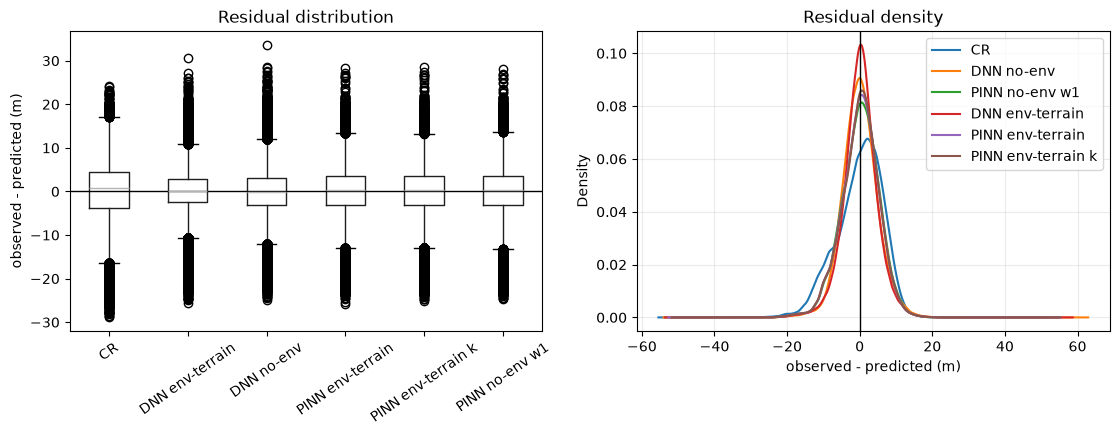

In [8]:
plot_df = predictions[predictions["model"].isin(CORE_MODELS)].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_df.boxplot(column="residual", by="model", ax=axes[0], grid=False, rot=35)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Residual distribution")
axes[0].set_xlabel("")
axes[0].set_ylabel("observed - predicted (m)")

for model, group in plot_df.groupby("model", sort=False):
    group["residual"].plot.kde(ax=axes[1], label=model)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Residual density")
axes[1].set_xlabel("observed - predicted (m)")
axes[1].legend()
plt.suptitle("")


## Age And Year Structure

These plots test whether the leftover errors are concentrated in particular stand ages or survey years. That matters because a model can have a decent RMSE while still missing a biologically important growth-stage pattern.

In [9]:
age_bins = [-np.inf, 30, 40, 60, 80, np.inf]
age_labels = ["<30", "30-40", "40-60", "60-80", "80+"]
plot_df["age_band"] = pd.cut(plot_df["Age"], bins=age_bins, labels=age_labels)

age_summary = (
    plot_df.groupby(["model", "age_band"], observed=True)
    .agg(n=("residual", "size"), bias=("residual", "mean"), mae=("residual", lambda x: np.mean(np.abs(x))), rmse=("residual", lambda x: np.sqrt(np.mean(x ** 2))))
    .reset_index()
)
age_summary

,model,age_band,n,bias,mae,rmse
0,CR,<30,56074,-0.550642,3.477685,4.459759
1,CR,30-40,76227,0.111331,4.958790,6.003693
2,CR,40-60,73909,0.558551,5.848855,7.064276
3,CR,60-80,21184,-0.236597,6.193129,8.000823
4,CR,80+,5054,-3.116130,6.477125,8.426818
5,DNN env-terrain,<30,56067,0.186891,2.499696,3.344267
6,DNN env-terrain,30-40,76198,0.041202,3.026239,3.882176
7,DNN env-terrain,40-60,73825,0.140208,3.975273,5.109247
8,DNN env-terrain,60-80,21155,0.376803,5.588451,7.035523
9,DNN env-terrain,80+,5047,-0.231054,6.249130,7.730057


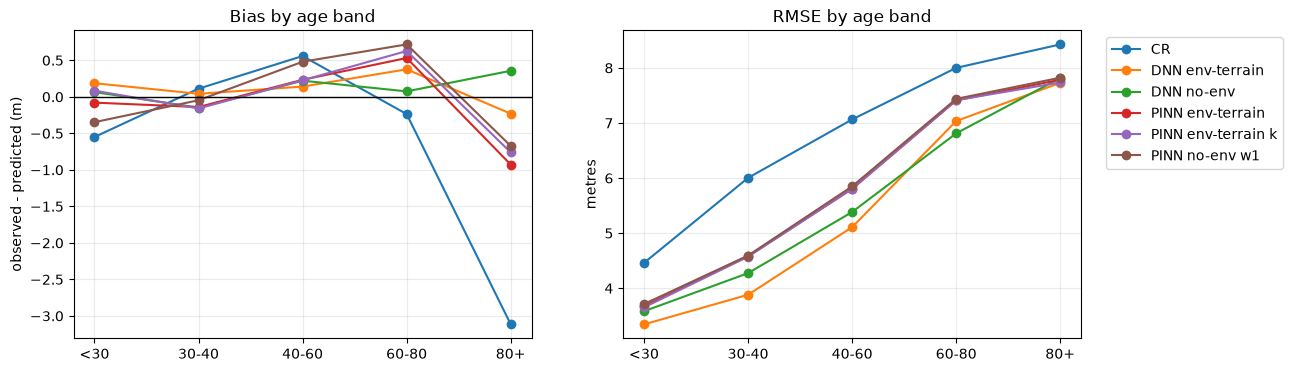

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for model, group in age_summary.groupby("model", sort=False):
    axes[0].plot(group["age_band"].astype(str), group["bias"], marker="o", label=model)
    axes[1].plot(group["age_band"].astype(str), group["rmse"], marker="o", label=model)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Bias by age band")
axes[0].set_ylabel("observed - predicted (m)")
axes[1].set_title("RMSE by age band")
axes[1].set_ylabel("metres")
axes[1].legend(bbox_to_anchor=(1.04, 1), loc="upper left")


,model,LiDAR_year,n,bias,rmse
0,CR,2008,58112,-1.184516,5.222974
1,CR,2012,58112,-0.524959,5.778750
2,CR,2021,58112,0.545680,6.769356
3,CR,2023,58112,1.131626,7.277047
4,DNN env-terrain,2008,58073,0.038397,3.896610
5,DNN env-terrain,2012,58073,-0.118619,4.474865
6,DNN env-terrain,2021,58073,0.064002,4.900580
7,DNN env-terrain,2023,58073,0.546138,5.268673
8,DNN no-env,2008,58112,-0.018782,4.198075
9,DNN no-env,2012,58112,-0.215878,4.674796


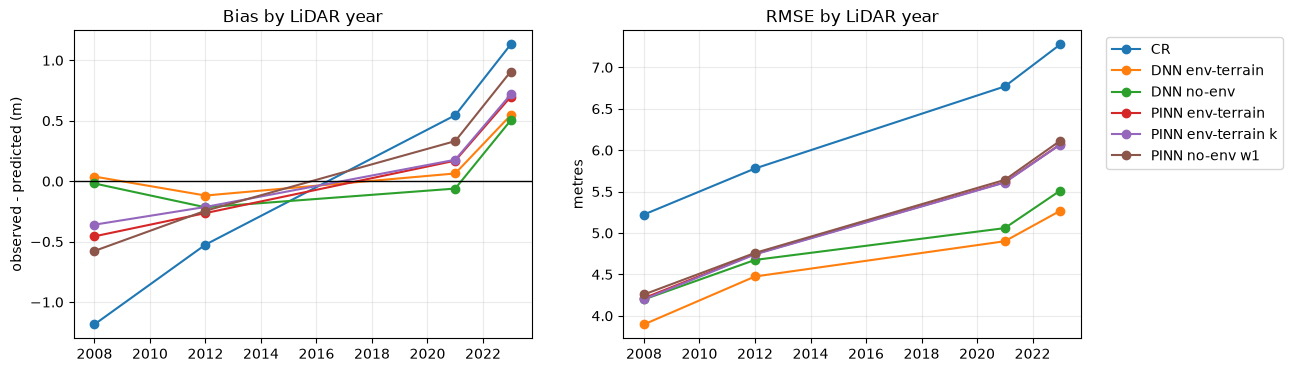

In [11]:
year_summary = (
    plot_df.groupby(["model", "LiDAR_year"])
    .agg(n=("residual", "size"), bias=("residual", "mean"), rmse=("residual", lambda x: np.sqrt(np.mean(x ** 2))))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for model, group in year_summary.groupby("model", sort=False):
    axes[0].plot(group["LiDAR_year"], group["bias"], marker="o", label=model)
    axes[1].plot(group["LiDAR_year"], group["rmse"], marker="o", label=model)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Bias by LiDAR year")
axes[0].set_ylabel("observed - predicted (m)")
axes[1].set_title("RMSE by LiDAR year")
axes[1].set_ylabel("metres")
axes[1].legend(bbox_to_anchor=(1.04, 1), loc="upper left")

year_summary

## Compartment-Level Bias

Spatial block testing holds out whole areas, so compartment-level residual means are a useful way to see whether a model is still systematically too high/low in particular forest compartments.

In [12]:
cpmt_summary = (
    plot_df.groupby(["model", "cpmt"])
    .agg(n=("residual", "size"), bias=("residual", "mean"), rmse=("residual", lambda x: np.sqrt(np.mean(x ** 2))))
    .reset_index()
)

cpmt_spread = (
    cpmt_summary.groupby("model")
    .agg(n_compartments=("cpmt", "nunique"), mean_abs_cpmt_bias=("bias", lambda x: np.mean(np.abs(x))), max_abs_cpmt_bias=("bias", lambda x: np.max(np.abs(x))))
    .sort_values("mean_abs_cpmt_bias")
)
cpmt_spread

,n_compartments,mean_abs_cpmt_bias,max_abs_cpmt_bias
model,,,
DNN env-terrain,232,2.543102,15.484021
DNN no-env,232,2.742114,14.489693
PINN env-terrain,232,3.163602,16.388784
PINN env-terrain k,232,3.172168,16.066277
PINN no-env w1,232,3.190583,16.145913
CR,232,4.138695,21.668115


model,CR,DNN env-terrain,DNN no-env,PINN env-terrain,PINN env-terrain k,PINN no-env w1
cpmt,,,,,,
1036,-21.668115,-11.768276,-10.697887,-16.388784,-16.066277,-16.145913
2244,-16.496610,-15.484021,-14.489693,-14.913536,-14.805900,-14.659965
2069,-15.860816,-10.819655,-7.073254,-10.449217,-10.733764,-10.673728
2134,-15.034822,-4.509665,-9.575022,-11.929348,-11.667135,-11.746285
2199,-14.725144,-8.038628,-6.196655,-10.298966,-10.286936,-9.936164
1059,-13.613431,-4.918655,-4.671054,-9.166490,-9.082268,-8.899250
2070,-13.546933,-9.275354,-6.744803,-9.724246,-9.653290,-9.296501
2071,-13.514533,-5.962120,-6.516981,-9.258794,-9.017926,-9.081322
1105,-13.210997,-8.631135,-5.620014,-10.425980,-9.934026,-10.080817


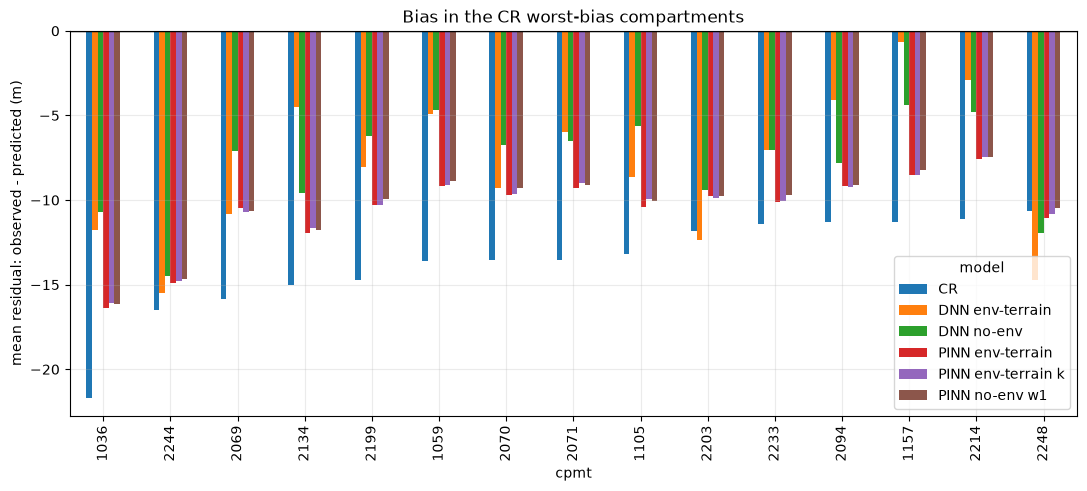

In [13]:
reference_model = "CR"
top_compartments = (
    cpmt_summary[cpmt_summary["model"] == reference_model]
    .assign(abs_bias=lambda d: d["bias"].abs())
    .sort_values("abs_bias", ascending=False)
    .head(15)["cpmt"]
)

top_cpmt = cpmt_summary[cpmt_summary["cpmt"].isin(top_compartments)].copy()
pivot = top_cpmt.pivot(index="cpmt", columns="model", values="bias").loc[top_compartments]
pivot.plot.bar(figsize=(13, 5))
plt.axhline(0, color="black", linewidth=1)
plt.title(f"Bias in the {reference_model} worst-bias compartments")
plt.ylabel("mean residual: observed - predicted (m)")

pivot

## Worst-Error Concentration

This section tests whether the largest errors are diffuse random noise or concentrated in specific ages, years, compartments, and repeat-offender plots.

The default focus model is `DNN no-env`, because it is the strongest core single-run model in the primary `4survey spatial_block` comparison. Change `FOCUS_MODEL` to repeat the same check for another model.

In [14]:
FOCUS_MODEL = "DNN no-env"
N_WORST = 100

focus_df = predictions[predictions["model"] == FOCUS_MODEL].copy()
focus_df["abs_error"] = focus_df["residual"].abs()
focus_df["age_band"] = pd.cut(focus_df["Age"], bins=age_bins, labels=age_labels)
worst_df = focus_df.nlargest(N_WORST, "abs_error").copy()

worst_overview = pd.Series({
    "focus_model": FOCUS_MODEL,
    "n_rows_population": len(focus_df),
    "n_plots_population": focus_df["identification"].nunique(),
    "n_compartments_population": focus_df["cpmt"].nunique(),
    "n_worst_rows": len(worst_df),
    "n_worst_plots": worst_df["identification"].nunique(),
    "n_worst_compartments": worst_df["cpmt"].nunique(),
    "worst_mean_age": worst_df["Age"].mean(),
    "population_mean_age": focus_df["Age"].mean(),
    "worst_min_observed_height": worst_df["observed_top_height"].min(),
    "worst_max_observed_height": worst_df["observed_top_height"].max(),
    "repeat_offender_rows": worst_df.duplicated("identification", keep=False).sum(),
    "repeat_offender_plots": (worst_df["identification"].value_counts() > 1).sum(),
    "max_rows_for_one_plot": worst_df["identification"].value_counts().max(),
})
worst_overview

focus_model                  DNN no-env
n_rows_population                232448
n_plots_population                58112
n_compartments_population           232
n_worst_rows                        100
n_worst_plots                        82
n_worst_compartments                 23
worst_mean_age                    55.97
population_mean_age           41.060745
worst_min_observed_height      3.503202
worst_max_observed_height      51.91116
repeat_offender_rows                 31
repeat_offender_plots                13
max_rows_for_one_plot                 4
dtype: object

In [15]:
def share_table(series_worst, series_population, label):
    out = pd.DataFrame({
        f"worst_{N_WORST}_pct": series_worst,
        "population_pct": series_population,
    }).fillna(0)
    out["enrichment_ratio"] = out[f"worst_{N_WORST}_pct"] / out["population_pct"].replace(0, np.nan)
    out.index.name = label
    return out

age_concentration = share_table(
    worst_df["age_band"].value_counts(normalize=True, sort=False) * 100,
    focus_df["age_band"].value_counts(normalize=True, sort=False) * 100,
    "age_band",
)
year_concentration = share_table(
    worst_df["LiDAR_year"].value_counts(normalize=True).sort_index() * 100,
    focus_df["LiDAR_year"].value_counts(normalize=True).sort_index() * 100,
    "LiDAR_year",
)

print("Age concentration")
display(age_concentration.round(2))
print("Year concentration")
display(year_concentration.round(2))

Age concentration


,worst_100_pct,population_pct,enrichment_ratio
age_band,,,
<30,13.0,24.12,0.54
30-40,7.0,32.79,0.21
40-60,39.0,31.80,1.23
60-80,33.0,9.11,3.62
80+,8.0,2.17,3.68


Year concentration


,worst_100_pct,population_pct,enrichment_ratio
LiDAR_year,,,
2008,18.0,25.0,0.72
2012,22.0,25.0,0.88
2021,28.0,25.0,1.12
2023,32.0,25.0,1.28


In [16]:
top_worst_compartments = worst_df["cpmt"].value_counts().rename_axis("cpmt").reset_index(name="worst_rows")
top_worst_compartments["worst_pct"] = 100 * top_worst_compartments["worst_rows"] / len(worst_df)
compartment_population_rows = focus_df["cpmt"].value_counts().rename_axis("cpmt").reset_index(name="population_rows")
top_worst_compartments = top_worst_compartments.merge(compartment_population_rows, on="cpmt", how="left")
top_worst_compartments["population_pct"] = 100 * top_worst_compartments["population_rows"] / len(focus_df)
top_worst_compartments["enrichment_ratio"] = top_worst_compartments["worst_pct"] / top_worst_compartments["population_pct"]

top_repeat_plots = (
    worst_df.groupby("identification")
    .agg(
        worst_rows=("abs_error", "size"),
        max_abs_error=("abs_error", "max"),
        cpmt=("cpmt", "first"),
        years=("LiDAR_year", lambda x: tuple(sorted(x))),
        age_min=("Age", "min"),
        age_max=("Age", "max"),
        observed_min=("observed_top_height", "min"),
        observed_max=("observed_top_height", "max"),
    )
    .query("worst_rows > 1")
    .sort_values(["worst_rows", "max_abs_error"], ascending=[False, False])
)

print("Top compartments among the worst errors")
display(top_worst_compartments.head(15).round(2))
print("Repeat-offender plots in the worst errors")
display(top_repeat_plots.head(20).round(2))

Top compartments among the worst errors


,cpmt,worst_rows,worst_pct,population_rows,population_pct,enrichment_ratio
0,2232,14,14.0,1968,0.85,16.54
1,2163,11,11.0,252,0.11,101.47
2,2219,11,11.0,1824,0.78,14.02
3,1097,10,10.0,332,0.14,70.01
4,1089,9,9.0,540,0.23,38.74
5,2176,5,5.0,1524,0.66,7.63
6,2244,5,5.0,100,0.04,116.22
7,2178,4,4.0,156,0.07,59.60
8,2092,4,4.0,1944,0.84,4.78
9,2173,4,4.0,3064,1.32,3.03


Repeat-offender plots in the worst errors


,worst_rows,max_abs_error,cpmt,years,age_min,age_max,observed_min,observed_max
identification,,,,,,,,
353952,4,28.55,2232,"(2008, 2012, 2021, 2023)",20,35,35.33,42.53
353950,4,27.35,2232,"(2008, 2012, 2021, 2023)",20,35,34.85,36.93
361944,3,24.25,2173,"(2008, 2021, 2023)",38,53,38.94,42.12
353991,2,26.66,2232,"(2008, 2012)",20,24,31.46,33.15
361055,2,26.09,2178,"(2008, 2012)",38,42,34.29,35.86
361056,2,25.25,2178,"(2008, 2012)",38,42,36.40,38.57
22422,2,24.34,2224,"(2021, 2023)",52,54,6.98,8.65
353945,2,24.24,2232,"(2008, 2012)",20,24,30.16,30.86
309024,2,23.92,1089,"(2008, 2012)",74,78,3.50,4.88


In [17]:
# Compare worst-error terrain/site values with the whole test population.
env_for_worst = pd.read_parquet(ROOT / "data" / "processed" / "environmental" / "plot_environmental_features.parquet")
env_for_worst = env_for_worst.drop_duplicates("identification")

terrain_check_cols = [
    "ceh_twi", "elevation", "topex", "northness", "eastness", "whcl",
    "slope_degrees", "plan_curvature", "dist_to_watercourse", "dist_to_road",
]
terrain_check_cols = [c for c in terrain_check_cols if c in env_for_worst.columns]

focus_with_env = focus_df.merge(env_for_worst[["identification", *terrain_check_cols]], on="identification", how="left")
worst_with_env = worst_df.merge(env_for_worst[["identification", *terrain_check_cols]], on="identification", how="left")

terrain_rows = []
for col in terrain_check_cols:
    pop_values = focus_with_env[col].dropna()
    worst_values = worst_with_env[col].dropna()
    if len(worst_values) == 0 or len(pop_values) == 0:
        continue
    terrain_rows.append({
        "variable": col,
        "worst_median": worst_values.median(),
        "population_median": pop_values.median(),
        "worst_p10": worst_values.quantile(0.10),
        "worst_p90": worst_values.quantile(0.90),
        "population_p10": pop_values.quantile(0.10),
        "population_p90": pop_values.quantile(0.90),
    })
terrain_worst_summary = pd.DataFrame(terrain_rows)
terrain_worst_summary.round(3)

,variable,worst_median,population_median,worst_p10,worst_p90,population_p10,population_p90
0,ceh_twi,6.877,7.191,5.912,11.238,6.085,9.440
1,elevation,110.000,150.200,33.500,224.000,59.800,359.100
2,topex,4.901,0.407,-14.904,15.934,-23.105,23.611
3,northness,0.174,0.048,-0.739,0.968,-0.954,0.981
4,eastness,0.742,0.139,-0.553,0.977,-0.812,0.957
5,whcl,4.000,4.000,2.000,4.000,2.000,6.000
6,slope_degrees,6.072,8.789,2.178,16.473,2.758,18.110
7,plan_curvature,0.003,0.001,-0.011,0.018,-0.007,0.010
8,dist_to_watercourse,239.678,444.687,57.539,769.313,122.600,992.574
9,dist_to_road,73.304,169.958,16.297,266.734,30.747,843.548


In [18]:
# Repeat the concentration check for all core models, so we do not overgeneralise from one model.
concentration_rows = []
for model in CORE_MODELS:
    sub = predictions[predictions["model"] == model].copy()
    if sub.empty:
        continue
    sub["abs_error"] = sub["residual"].abs()
    sub["age_band"] = pd.cut(sub["Age"], bins=age_bins, labels=age_labels)
    worst = sub.nlargest(N_WORST, "abs_error")
    older_worst_share = worst["age_band"].isin(["60-80", "80+"]).mean()
    recent_worst_share = worst["LiDAR_year"].isin([2021, 2023]).mean()
    top3_cpmt_rows = worst["cpmt"].value_counts().head(3).sum()
    concentration_rows.append({
        "model": model,
        "worst_mean_age": worst["Age"].mean(),
        "population_mean_age": sub["Age"].mean(),
        "worst_60plus_pct": 100 * older_worst_share,
        "population_60plus_pct": 100 * sub["age_band"].isin(["60-80", "80+"]).mean(),
        "worst_2021_2023_pct": 100 * recent_worst_share,
        "population_2021_2023_pct": 100 * sub["LiDAR_year"].isin([2021, 2023]).mean(),
        "worst_compartments": worst["cpmt"].nunique(),
        "population_compartments": sub["cpmt"].nunique(),
        "top3_compartment_worst_rows": top3_cpmt_rows,
        "repeat_offender_plots": int((worst["identification"].value_counts() > 1).sum()),
    })
concentration_summary = pd.DataFrame(concentration_rows)
concentration_summary.round(2)

,model,worst_mean_age,population_mean_age,worst_60plus_pct,population_60plus_pct,worst_2021_2023_pct,population_2021_2023_pct,worst_compartments,population_compartments,top3_compartment_worst_rows,repeat_offender_plots
0,CR,77.96,41.06,100.0,11.29,65.0,50.0,16,232,55,34
1,DNN no-env,55.97,41.06,41.0,11.29,60.0,50.0,23,232,36,13
2,PINN no-env w1,65.24,41.06,53.0,11.29,79.0,50.0,21,232,49,30
3,DNN env-terrain,64.34,41.05,63.0,11.28,54.0,50.0,30,232,38,23
4,PINN env-terrain,64.61,41.05,52.0,11.28,78.0,50.0,23,232,41,30
5,PINN env-terrain k,62.02,41.05,45.0,11.28,78.0,50.0,23,232,41,31


Interpretation guide:

- If the worst errors are concentrated in older stands, recent years, a few compartments, and repeated plots, that is evidence against a purely diffuse random-noise explanation.
- It is not proof of data corruption. Plausible observed heights mean the extreme rows are not obviously impossible measurements.
- It is also not proof that terrain is the dominant missing driver. If the terrain summaries are not extreme, the worst cases may reflect compartment history, local disturbance, species/stand definition issues, edge effects, or unmeasured site variables.

## Join Residuals To Coordinates And Environmental Variables

For spatial and environmental diagnostics, use one row per plot per model: the mean held-out residual across that plot's test years. This avoids treating repeated survey years from the same plot as independent spatial samples.

In [19]:
plot_residuals = (
    plot_df.groupby(["model", "identification", "cpmt"], as_index=False)
    .agg(
        mean_residual=("residual", "mean"),
        mean_abs_residual=("residual", lambda x: np.mean(np.abs(x))),
        n_years=("LiDAR_year", "nunique"),
        mean_age=("Age", "mean"),
        mean_observed_height=("observed_top_height", "mean"),
    )
)

env_path = ROOT / "data" / "processed" / "environmental" / "plot_environmental_features.parquet"
coords_path = ROOT / "data" / "interim" / "plot_coordinates.csv.gz"
env = pd.read_parquet(env_path)
coords = pd.read_csv(coords_path)

join_cols = ["identification", "cpmt"]
env_unique = env.drop_duplicates("identification")
coords_unique = coords.drop_duplicates("identification")

residual_env = plot_residuals.merge(coords_unique, on=join_cols, how="left", suffixes=("", "_coord"))
env_extra_cols = [c for c in env_unique.columns if c not in residual_env.columns or c in ["identification", "cpmt"]]
residual_env = residual_env.merge(env_unique[env_extra_cols], on=join_cols, how="left")

print(residual_env.shape)
residual_env.head()

(348555, 81)


,model,identification,cpmt,mean_residual,mean_abs_residual,n_years,mean_age,mean_observed_height,x,y,mean_cr_residual_4survey,mean_cr_residual_6survey,groundfrost_mean_4survey,groundfrost_mean_6survey,rainfall_mean_4survey,rainfall_mean_6survey,sfcWind_mean_4survey,sfcWind_mean_6survey,sun_mean_4survey,sun_mean_6survey,tas_mean_4survey,tas_mean_6survey,tasmax_mean_4survey,tasmax_mean_6survey,tasmin_mean_4survey,tasmin_mean_6survey,era5_land_temp_k,ceh_pedotope,ceh_twi,ceh_subsurface_drainage,ceh_textural_composition,soilgrids_ph,chelsa_bio1_celsius,chelsa_gdd5_degc,chelsa_bio12_precip_mm,gwa_wind_speed_10m,dist_to_cpmt_boundary,dist_to_forest_perimeter,scpt,blk,dist_to_scpt_boundary,dist_to_block_boundary,cpmt_compactness_ratio,elevation_roughness,neighbour_mean_height,neighbour_height_differential,slope_degrees,aspect_degrees,profile_curvature,plan_curvature,tpi,frost_hollow_flag,solar_radiation_index,inverse_slope_proxy,dist_to_watercourse,dist_to_road,topex,elevation,windward_topex,northness,eastness,whcl,Age,CanopyCover,Thin,time_since_thinning,time_since_thinning_missing,recent_thinning_5yr,yldc,gwa_weibull_a_10m,gwa_weibull_k_10m,gwa_wind_speed_50m,gwa_weibull_a_50m,gwa_weibull_k_50m,gwa_wind_p95_10m,gwa_prob_above_critical_10m,gwa_wind_p95_50m,gwa_prob_above_critical_50m,tpi_250m,tpi_500m,local_relief_500m
0,CR,8897,2250,-0.291803,0.545805,4,79.0,30.330592,248295.406000,696888.497500,-0.913986,-6.040605,9.44421,9.342458,173.312633,180.648545,4.220529,4.276532,106.77217,104.458312,8.49504,8.577053,12.546852,12.606936,4.537472,4.652025,273.408344,11.0,12.085580,1.0,4.0,4.5,8.55,1420.4,2222.4,0.452051,2.816369,73.826610,I,30,3.854832,10.000000,0.021091,3.996090,25.862340,6.245065,2.303445,145.124672,-0.001143,-0.012528,-4.108,1.0,0.858555,-2.303445,692.081588,23.724844,2.548900,129.2,0.847916,-0.820398,0.571793,2,79.0,0.766226,0.0,0.0,1.0,0.0,20,0.498375,1.446191,4.886473,5.474103,1.688830,1.064252,3.065505e-91,10.482447,0.000134,-9.681821,-11.295922,68.000000
1,CR,8898,2250,0.920356,1.112114,4,79.0,31.542751,248315.406000,696888.497500,0.298173,-4.915707,9.44421,9.342458,173.312633,180.648545,4.220529,4.276532,106.77217,104.458312,8.49504,8.577053,12.546852,12.606936,4.537472,4.652025,273.408344,11.0,12.031609,1.0,4.0,4.5,8.55,1420.4,2222.4,0.452051,4.950966,55.087470,I,30,4.499327,10.000000,0.021091,4.218500,26.194137,8.114915,2.749279,121.373005,-0.000478,-0.023947,-4.916,1.0,0.853942,-2.749279,697.986876,22.350609,2.651887,127.0,0.286477,-0.520607,0.853796,2,79.0,0.851314,0.0,0.0,1.0,0.0,20,0.498375,1.446191,4.886473,5.474103,1.688830,1.064252,3.065505e-91,10.482447,0.000134,-10.209917,-11.655556,66.300003
2,CR,8899,2250,-7.004951,7.004951,4,79.0,23.617444,248215.406000,696988.497500,-7.627134,-12.155625,9.44421,9.342458,173.312633,180.648545,4.220529,4.276532,106.77217,104.458312,8.49504,8.577053,12.546852,12.606936,4.537472,4.652025,273.408344,11.0,6.642655,1.0,4.0,4.3,8.45,1403.5,2277.8,0.452051,14.142136,191.537314,I,30,13.013631,14.142136,0.021091,5.853838,23.109297,1.109239,5.599719,178.246595,0.000501,0.006337,1.324,0.0,0.890106,-5.599719,768.983137,66.798666,0.778446,140.0,0.275018,-0.999532,0.030598,2,79.0,0.827243,0.0,0.0,1.0,0.0,20,1.392850,1.148084,5.033704,5.633547,1.666472,3.621983,5.590509e-10,10.882208,0.000259,-1.747108,-4.022676,64.000000
3,CR,8900,2250,-8.375684,8.375684,4,79.0,22.246711,248252.693495,696879.273795,-8.997867,-13.881467,9.44421,9.342458,173.312633,180.648545,4.220529,4.276532,106.77217,104.458312,8.49504,8.577053,12.546852,12.606936,4.537472,4.652025,273.408344,11.0,12.085580,1.0,4.0,4.4,8.45,1403.5,2277.8,0.452051,17.961872,112.699693,I,30,4.261796,15.090803,0.021091,3.996090,25.241732,0.397096,2.303445,145.124672,-0.001143,-0.012528,-4.108,1.0,0.858555,-2.303445,670.790991,10.618842,2.548900,129.2,0.847916,-0.820398,0.571793,2,79.0,0.578156,0.0,0.0,1.0,0.0,20,0.323091,1.474133,4.872352,5.459115,1.692496,0.680091,7.821484e-191,10.439045,0.000123,-9.681821,-11.295922,68.000000
4,CR,89

## Spatial Residual Maps

These maps are visual diagnostics only. Look for whether the same high/low residual zones visible in the Chapman-Richards map remain in the DNN/PINN maps.

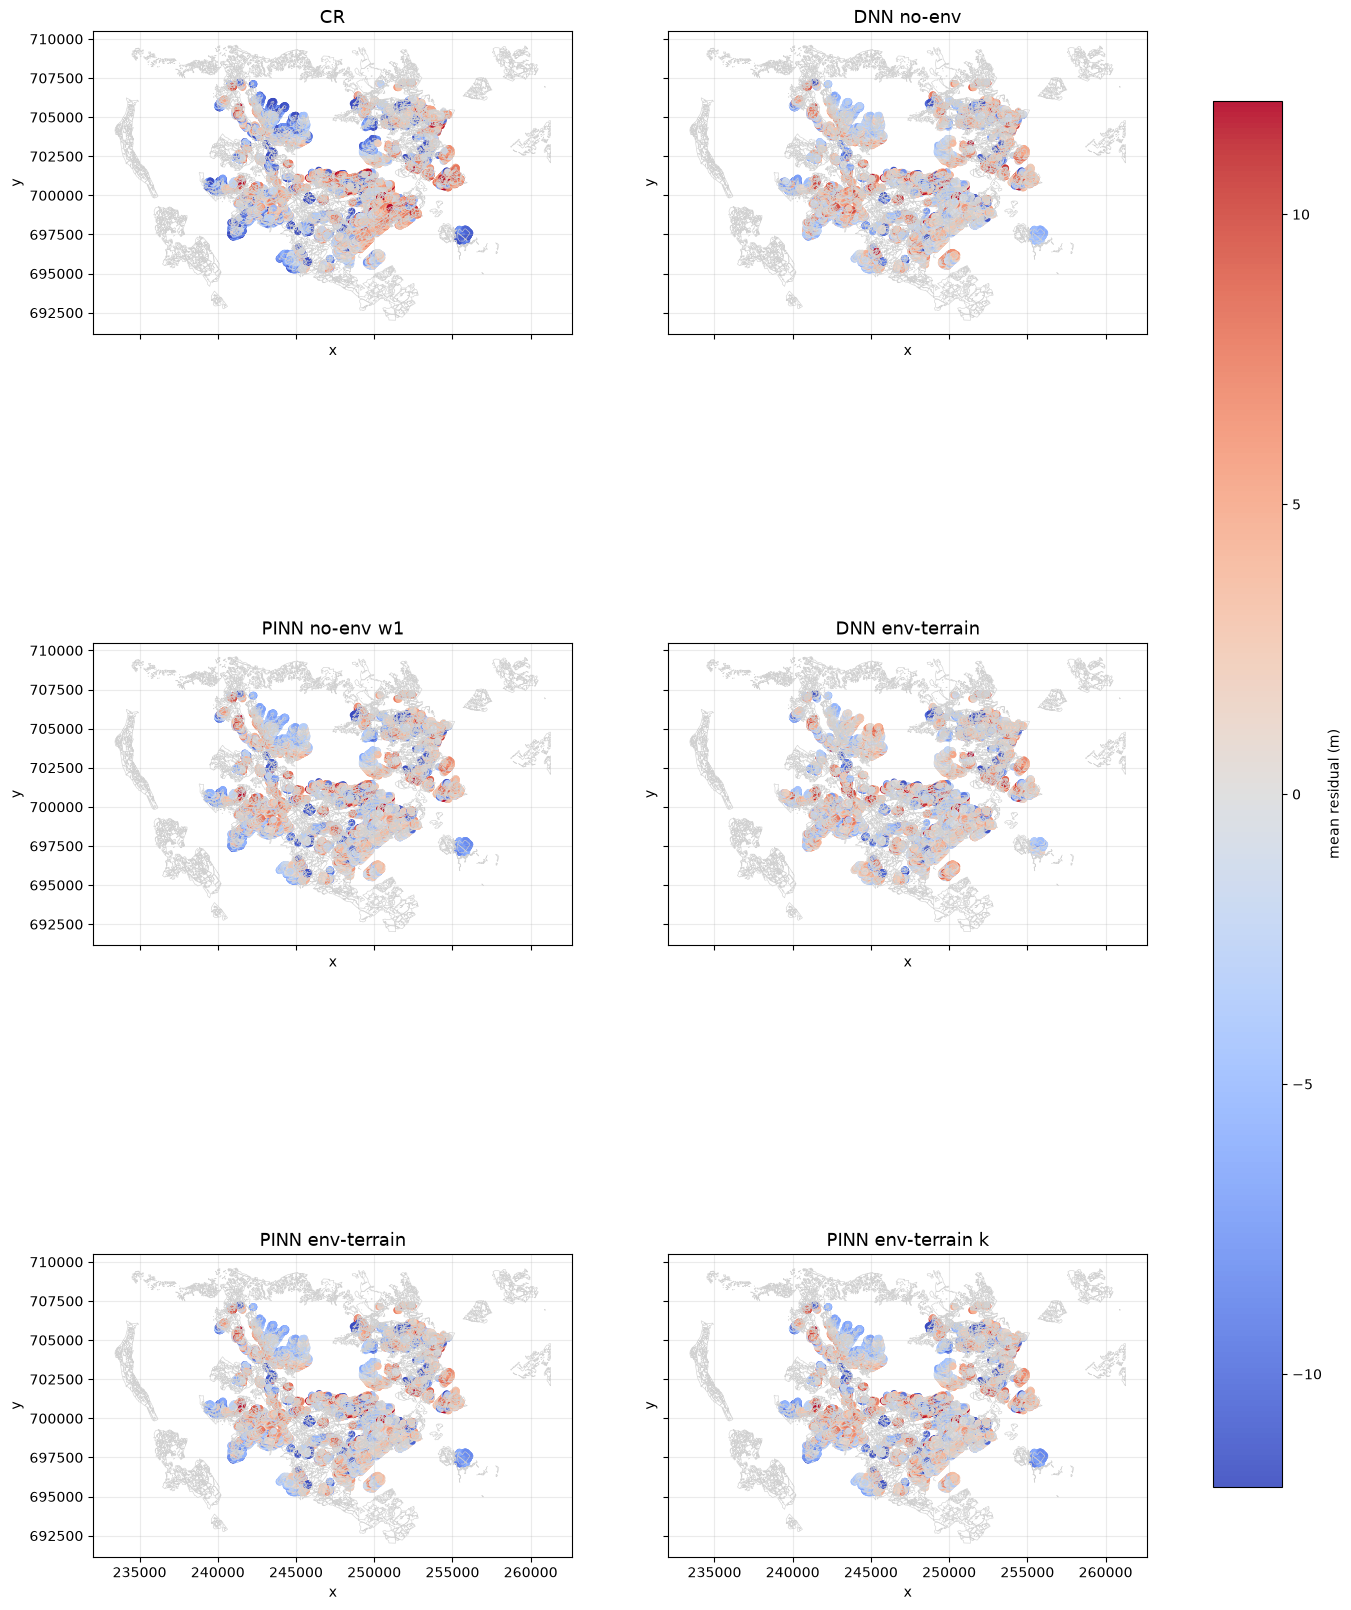

In [20]:
map_models = [m for m in CORE_MODELS if m in residual_env["model"].unique()]
vmax = np.nanpercentile(np.abs(residual_env[residual_env["model"].isin(map_models)]["mean_residual"]), 98)

def load_compartment_boundaries_optional():
    try:
        from models.common.geo import load_compartment_boundaries
        return load_compartment_boundaries()
    except Exception as exc:
        print(f"Compartment boundary overlay skipped: {type(exc).__name__}: {exc}")
        return None

def plot_compartment_background(ax, boundaries=None, cpmts=None, color="#d0d0d0", linewidth=0.35, alpha=0.9):
    if boundaries is None:
        return
    plot_boundaries = boundaries
    if cpmts is not None:
        plot_boundaries = plot_boundaries[plot_boundaries["cpmt"].isin(cpmts)]
    if len(plot_boundaries) == 0:
        return
    try:
        plot_boundaries.boundary.plot(ax=ax, color=color, linewidth=linewidth, alpha=alpha)
    except Exception as exc:
        print(f"Boundary overlay failed: {type(exc).__name__}: {exc}")

compartment_boundaries = load_compartment_boundaries_optional()

n_cols = min(2, len(map_models))
n_rows = int(np.ceil(len(map_models) / n_cols))
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(8.5 * n_cols, 7.5 * n_rows),
    sharex=True,
    sharey=True,
    squeeze=False,
)
axes_flat = axes.ravel()

for ax, model in zip(axes_flat, map_models):
    sub = residual_env[residual_env["model"] == model].dropna(subset=["x", "y"])
    plot_compartment_background(ax, compartment_boundaries, linewidth=0.45, alpha=0.95)
    sc = ax.scatter(
        sub["x"],
        sub["y"],
        c=sub["mean_residual"],
        cmap="coolwarm",
        vmin=-vmax,
        vmax=vmax,
        s=16,
        alpha=0.9,
    )
    ax.set_title(model, fontsize=13)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

for ax in axes_flat[len(map_models):]:
    ax.set_visible(False)

fig.colorbar(sc, ax=axes_flat[:len(map_models)], shrink=0.8, label="mean residual (m)")


## Worst-Error And Problem-Compartment Maps

These maps connect the tabular worst-error analysis to geography. They answer: are the worst errors scattered across the forest, or concentrated in a few places?

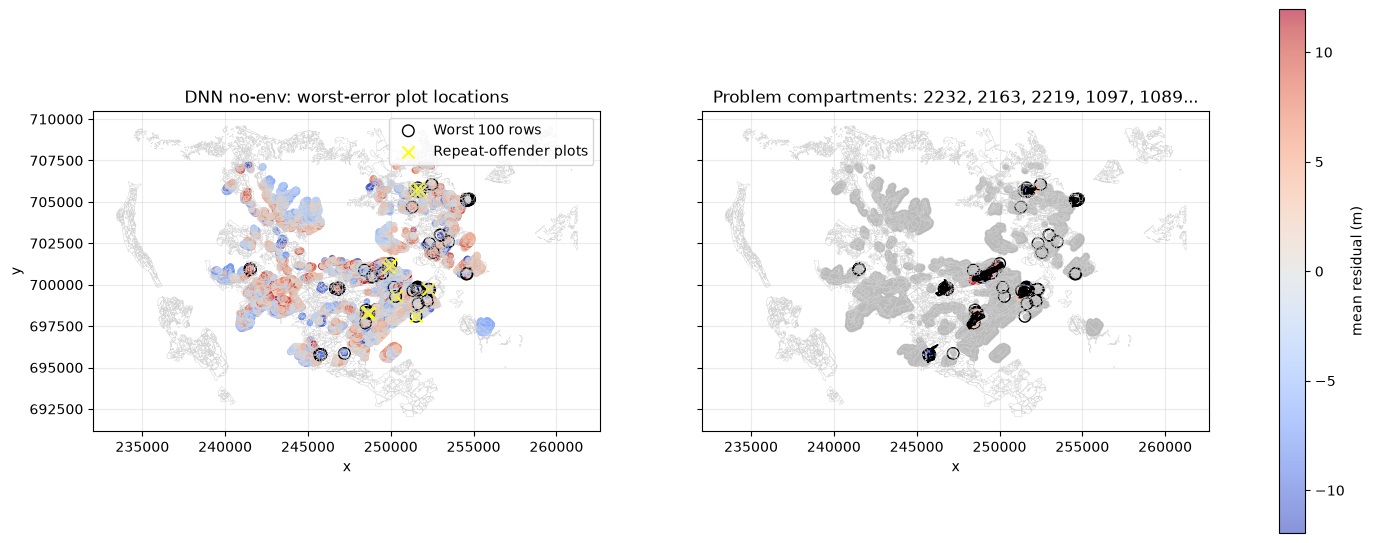

In [21]:
# Map the focus model's worst rows and the compartments most represented in those rows.
problem_cpmts = top_worst_compartments.head(8)["cpmt"].tolist()
problem_labels = ", ".join(str(c) for c in problem_cpmts[:5])

focus_plot_residuals = residual_env[residual_env["model"] == FOCUS_MODEL].copy()
worst_plot_ids = set(worst_df["identification"])
repeat_plot_ids = set(top_repeat_plots.index)

focus_plot_residuals["in_worst_rows"] = focus_plot_residuals["identification"].isin(worst_plot_ids)
focus_plot_residuals["repeat_offender"] = focus_plot_residuals["identification"].isin(repeat_plot_ids)
focus_plot_residuals["problem_cpmt"] = focus_plot_residuals["cpmt"].isin(problem_cpmts)

fig, axes = plt.subplots(1, 2, figsize=(18, 8.5), sharex=True, sharey=True)

# Left: all plot residuals, with the worst-error points overlaid.
plot_compartment_background(axes[0], compartment_boundaries)
base = focus_plot_residuals.dropna(subset=["x", "y"])
sc = axes[0].scatter(base["x"], base["y"], c=base["mean_residual"], cmap="coolwarm", vmin=-vmax, vmax=vmax, s=13, alpha=0.6)
worst_points = base[base["in_worst_rows"]]
repeat_points = base[base["repeat_offender"]]
axes[0].scatter(worst_points["x"], worst_points["y"], facecolors="none", edgecolors="black", s=70, linewidths=1.0, label=f"Worst {N_WORST} rows")
axes[0].scatter(repeat_points["x"], repeat_points["y"], marker="x", color="yellow", s=76, linewidths=1.5, label="Repeat-offender plots")
axes[0].set_title(f"{FOCUS_MODEL}: worst-error plot locations")
axes[0].legend(loc="best")

# Right: highlight problem compartments and all focus-model residuals inside/around them.
plot_compartment_background(axes[1], compartment_boundaries)
plot_compartment_background(axes[1], compartment_boundaries, cpmts=problem_cpmts, color="black", linewidth=1.2, alpha=1.0)
axes[1].scatter(base["x"], base["y"], color="#bbbbbb", s=9, alpha=0.25)
problem_points = base[base["problem_cpmt"]]
axes[1].scatter(problem_points["x"], problem_points["y"], c=problem_points["mean_residual"], cmap="coolwarm", vmin=-vmax, vmax=vmax, s=22, alpha=0.9)
axes[1].scatter(worst_points["x"], worst_points["y"], facecolors="none", edgecolors="black", s=70, linewidths=1.0)
axes[1].set_title(f"Problem compartments: {problem_labels}...")

for ax in axes:
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(sc, ax=axes, shrink=0.8, label="mean residual (m)")


## LISA Cluster Map

LISA, or Local Moran's I, identifies where residuals form statistically significant local clusters. This is stricter than simply mapping large errors: it asks whether a plot and its neighbours share unusually high or low residuals after correcting for many simultaneous local tests.

Labels:

- `High-High`: plot and neighbours have above-average residuals. The model tends to under-predict this local area.
- `Low-Low`: plot and neighbours have below-average residuals. The model tends to over-predict this local area.
- `High-Low` / `Low-High`: local spatial outliers.
- `Not significant`: no statistically clear local cluster for that plot.

Default uses `k=20` nearest neighbours and `199` permutations so the notebook remains usable. Increase to `999` for a final, slower version.

In [22]:
RUN_LISA = False
LISA_K = 20
LISA_PERMUTATIONS = 199

if RUN_LISA:
    try:
        from models.spatial_attribution.lisa import local_morans_i
        lisa_input = focus_plot_residuals.dropna(subset=["x", "y", "mean_residual"]).copy()
        labels, local_i, raw_p = local_morans_i(
            lisa_input["x"], lisa_input["y"], lisa_input["mean_residual"],
            k=LISA_K, permutations=LISA_PERMUTATIONS, seed=42,
        )
        lisa_input["lisa_label"] = labels
        lisa_input["local_morans_i"] = local_i
        lisa_input["raw_lisa_p"] = raw_p
        lisa_summary = lisa_input["lisa_label"].value_counts().rename_axis("lisa_label").reset_index(name="n_plots")
        lisa_summary["pct_plots"] = 100 * lisa_summary["n_plots"] / len(lisa_input)
        display(lisa_summary)
    except Exception as exc:
        lisa_input = pd.DataFrame()
        lisa_summary = pd.DataFrame({"message": [f"LISA skipped: {type(exc).__name__}: {exc}"]})
        display(lisa_summary)
else:
    lisa_input = pd.DataFrame()
    lisa_summary = pd.DataFrame({"message": ["LISA skipped because RUN_LISA=False"]})
    display(lisa_summary)

,message
0,LISA skipped because RUN_LISA=False


In [23]:
if len(lisa_input):
    lisa_colors = {
        "High-High": "#b2182b",
        "Low-Low": "#2166ac",
        "High-Low": "#ef8a62",
        "Low-High": "#67a9cf",
        "Not significant": "#d9d9d9",
    }
    lisa_order = ["High-High", "Low-Low", "High-Low", "Low-High", "Not significant"]

    fig, ax = plt.subplots(figsize=(13, 11))
    plot_compartment_background(ax, compartment_boundaries)
    for label in lisa_order:
        sub = lisa_input[lisa_input["lisa_label"] == label]
        if len(sub) == 0:
            continue
        ax.scatter(
            sub["x"], sub["y"],
            s=28 if label != "Not significant" else 10,
            color=lisa_colors[label],
            alpha=0.9 if label != "Not significant" else 0.25,
            label=f"{label} ({len(sub)})",
        )

    # Overlay repeated worst-error plots so you can see whether they sit inside significant clusters.
    if "repeat_offender" in focus_plot_residuals.columns:
        repeat_overlay = lisa_input[lisa_input["identification"].isin(repeat_plot_ids)]
        ax.scatter(repeat_overlay["x"], repeat_overlay["y"], marker="x", color="yellow", s=90, linewidths=1.6, label="Repeat-offender plots")

    plot_compartment_background(ax, compartment_boundaries, cpmts=problem_cpmts, color="black", linewidth=1.0, alpha=1.0)
    ax.set_title(f"{FOCUS_MODEL}: LISA residual clusters, k={LISA_K}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="best", fontsize=8)
else:
    print("No LISA map drawn because LISA did not run.")

No LISA map drawn because LISA did not run.


## Spatial Autocorrelation

This estimates the spatial range with a semivariogram and then calculates Moran's I at that distance. If the DNN/PINN has absorbed the spatial structure in the CR residuals, Moran's I should fall. If it stays high, important spatial structure remains unexplained.

This section is useful but slow, so it is opt-in by default. Set `RUN_GLOBAL_SPATIAL_AUTOCORR = True` in the next cell when you want the full test.

In [24]:
RUN_GLOBAL_SPATIAL_AUTOCORR = False

if RUN_GLOBAL_SPATIAL_AUTOCORR:
    try:
        from models.spatial_attribution.spatial_autocorrelation import semivariogram_range, global_morans_i
        spatial_rows = []
        for model in map_models:
            sub = residual_env[residual_env["model"] == model].dropna(subset=["x", "y", "mean_residual"])
            if len(sub) < 50:
                spatial_rows.append({"model": model, "n": len(sub), "range_m": np.nan, "range_status": "too_few_points", "morans_i": np.nan, "p_sim": np.nan})
                continue
            range_m, status = semivariogram_range(sub["x"], sub["y"], sub["mean_residual"], max_distance=5000, n_bins=15, sample_size=5000)
            if np.isfinite(range_m) and range_m > 0:
                morans_i, p_sim = global_morans_i(sub["x"], sub["y"], sub["mean_residual"], distance=range_m, sample_size=5000, permutations=999)
            else:
                morans_i, p_sim = np.nan, np.nan
            spatial_rows.append({"model": model, "n": len(sub), "range_m": range_m, "range_status": status, "morans_i": morans_i, "p_sim": p_sim})
        spatial_summary = pd.DataFrame(spatial_rows).sort_values("morans_i", na_position="last")
    except Exception as exc:
        spatial_summary = pd.DataFrame({"message": [f"Spatial autocorrelation skipped: {type(exc).__name__}: {exc}"]})
else:
    spatial_summary = pd.DataFrame({"message": ["Global spatial autocorrelation skipped because RUN_GLOBAL_SPATIAL_AUTOCORR=False"]})

spatial_summary

,message
0,Global spatial autocorrelation skipped because...


## Can Environmental/Site Variables Still Predict The Leftover Residuals?

This is the most direct bridge to the statistical residual analysis. For each model, fit a small secondary model to predict that model's held-out residuals from environmental/site variables. Lower secondary-model R2 means less environmental/site structure remains in the residuals.

Interpretation:

- High R2 for CR residuals: Chapman-Richards left environmental/site structure unexplained.
- Lower R2 for DNN/PINN residuals: that model absorbed some of the structure.
- Similar or higher R2 after DNN/PINN: the model did not capture that structure, even if its RMSE improved.

The feature list deliberately excludes observed height and mean age. Those variables are too close to the prediction target/residual definition and would make the diagnostic look stronger than it really is.

In [25]:
candidate_feature_cols = [
    "ceh_twi", "eastness", "elevation", "northness", "topex",
    "whcl", "plan_curvature", "profile_curvature", "slope_degrees", "aspect_degrees", "tpi",
    "chelsa_bio1_celsius", "chelsa_bio12_precip_mm", "chelsa_gdd5_degc", "soilgrids_ph",
    "dist_to_watercourse", "dist_to_road", "dist_to_cpmt_boundary", "dist_to_forest_perimeter",
    "gwa_wind_speed_10m", "windward_topex", "elevation_roughness", "frost_hollow_flag",
    "CanopyCover", "Thin", "recent_thinning_5yr", "time_since_thinning", "yldc",
]
feature_cols = [c for c in candidate_feature_cols if c in residual_env.columns]
feature_cols

['ceh_twi',
 'eastness',
 'elevation',
 'northness',
 'topex',
 'whcl',
 'plan_curvature',
 'profile_curvature',
 'slope_degrees',
 'aspect_degrees',
 'tpi',
 'chelsa_bio1_celsius',
 'chelsa_bio12_precip_mm',
 'chelsa_gdd5_degc',
 'soilgrids_ph',
 'dist_to_watercourse',
 'dist_to_road',
 'dist_to_cpmt_boundary',
 'dist_to_forest_perimeter',
 'gwa_wind_speed_10m',
 'windward_topex',
 'elevation_roughness',
 'frost_hollow_flag',
 'CanopyCover',
 'Thin',
 'recent_thinning_5yr',
 'time_since_thinning',
 'yldc']

In [26]:
RUN_RESIDUAL_RF = False  # set True for a slower nonlinear residual-predictability check


def residual_predictability_for_model(df, model, feature_cols, estimator_name="ridge"):
    sub = df[df["model"] == model].dropna(subset=["mean_residual"]).copy()
    X = sub[feature_cols]
    y = sub["mean_residual"].to_numpy(dtype=float)
    if len(sub) < 100:
        return {"model": model, "estimator": estimator_name, "n": len(sub), "cv_r2": np.nan, "cv_mae": np.nan, "note": "too_few_rows"}

    if estimator_name == "ridge":
        estimator = Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("model", RidgeCV(alphas=np.logspace(-3, 3, 13))),
        ])
    elif estimator_name == "rf":
        estimator = Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(n_estimators=80, max_depth=6, min_samples_leaf=30, random_state=42, n_jobs=-1)),
        ])
    else:
        raise ValueError(estimator_name)

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    pred = cross_val_predict(estimator, X, y, cv=cv, n_jobs=None)
    return {
        "model": model,
        "estimator": estimator_name,
        "n": len(sub),
        "cv_r2": r2_score(y, pred),
        "cv_mae": mean_absolute_error(y, pred),
        "residual_sd": np.std(y, ddof=1),
        "note": "",
    }

predictability_rows = []
estimators_to_run = ["ridge"] + (["rf"] if RUN_RESIDUAL_RF else [])
for model in map_models:
    for estimator_name in estimators_to_run:
        predictability_rows.append(residual_predictability_for_model(residual_env, model, feature_cols, estimator_name=estimator_name))

predictability = pd.DataFrame(predictability_rows).sort_values(["estimator", "cv_r2"], ascending=[True, False])
predictability

,model,estimator,n,cv_r2,cv_mae,residual_sd,note
0,CR,ridge,58112,0.497777,3.285985,5.983669,
5,PINN env-terrain k,ridge,58073,0.283829,3.189927,4.879998,
4,PINN env-terrain,ridge,58073,0.278262,3.206157,4.880997,
2,PINN no-env w1,ridge,58112,0.278238,3.222516,4.893734,
1,DNN no-env,ridge,58112,0.196155,3.060411,4.476094,
3,DNN env-terrain,ridge,58073,0.099919,3.073997,4.297252,


estimator,ridge
model,
CR,0.497777
DNN no-env,0.196155
PINN no-env w1,0.278238
DNN env-terrain,0.099919
PINN env-terrain,0.278262
PINN env-terrain k,0.283829


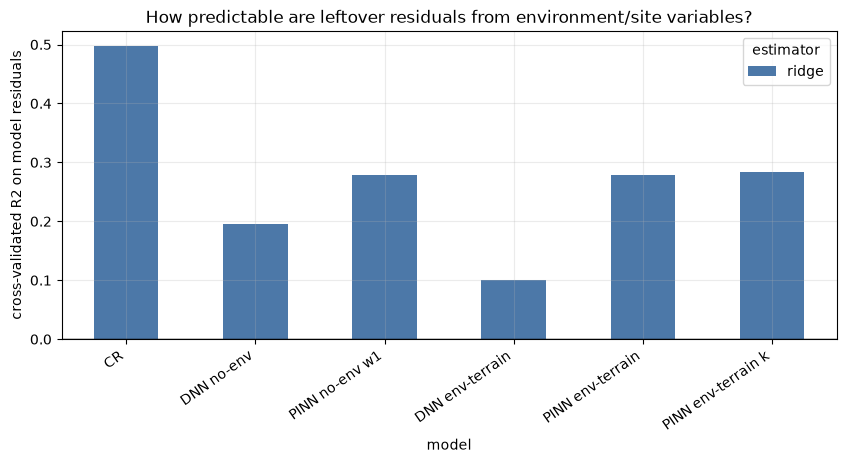

In [27]:
pivot_pred = predictability.pivot(index="model", columns="estimator", values="cv_r2").reindex(map_models)
pivot_pred.plot.bar(figsize=(10, 4), color=["#4c78a8", "#f58518"][:len(pivot_pred.columns)])
plt.axhline(0, color="black", linewidth=1)
plt.title("How predictable are leftover residuals from environment/site variables?")
plt.ylabel("cross-validated R2 on model residuals")
plt.xticks(rotation=35, ha="right")
pivot_pred

## Row-Level Residual Predictability (age-varying, not pooled per plot)

The residual-predictability check above uses `mean_residual`, one row per plot. That is conservative for spatial analysis, but it removes age/year variation. This optional section repeats the idea at row level, so it can ask whether environment/site variables explain individual-year errors.

This section is useful but slower, so it is opt-in by default. Set `RUN_ROW_LEVEL_RESIDUAL_PREDICTABILITY = True` in the next cell when you need it.

In [28]:
RUN_ROW_LEVEL_RESIDUAL_PREDICTABILITY = False

if RUN_ROW_LEVEL_RESIDUAL_PREDICTABILITY:
    # Row-level join -- same environmental/coordinate merge as plot_residuals above, but on
    # plot_df directly (one row per plot-survey-year), not the grouped-by-plot version.
    row_level_env = plot_df.merge(coords_unique, on=["identification", "cpmt"], how="left", suffixes=("", "_coord"))
    row_level_env = row_level_env.merge(env_unique[env_extra_cols], on=["identification", "cpmt"], how="left")
    # residual_predictability_for_model() expects a "mean_residual" column -- reusing the same
    # function as the pooled check above, not rewriting it; the name is a holdover from that
    # reuse, this is genuinely the row-level residual here, not a mean of anything.
    row_level_env = row_level_env.rename(columns={"residual": "mean_residual"})

    row_level_predictability_rows = []
    for model in map_models:
        for estimator_name in ["ridge", "rf"]:
            row_level_predictability_rows.append(
                residual_predictability_for_model(row_level_env, model, feature_cols, estimator_name)
            )
    row_level_predictability = pd.DataFrame(row_level_predictability_rows)
    row_level_pivot = row_level_predictability.pivot(index="model", columns="estimator", values="cv_r2").reindex(map_models)

    print("Pooled per-plot (mean_residual, averaged across years):")
    display(pivot_pred)
    print("Row-level (age-varying, one row per plot-survey-year):")
    display(row_level_pivot)
    print("Difference (row-level minus pooled), RF column -- positive means row-level finds MORE predictable structure:")
    (row_level_pivot["rf"] - pivot_pred["rf"]).round(4)
else:
    row_level_predictability = pd.DataFrame({
        "message": ["Row-level residual predictability skipped because RUN_ROW_LEVEL_RESIDUAL_PREDICTABILITY=False"]
    })
    row_delta_summary = pd.DataFrame()
    display(row_level_predictability)


,message
0,Row-level residual predictability skipped beca...


## Model-Failure Interpretation Table

This table is a structured summary of the current evidence for each hypothesis. Built from the live variables computed by the cells above in THIS run (`seed_delta_summary`, `concentration_summary`, `spatial_summary`, `pivot_pred`, `row_level_pivot`) -- not retyped prose. Re-executing this notebook regenerates every value in the table below from scratch, so it can't silently go stale the way a hardcoded version can.

In [29]:
from scipy.stats import t as t_dist

def fmt_delta(row):
    return f"mean={row['mean_delta_r2']:+.4f}, SD={row['sd_delta_r2']:.4f}, n={int(row['n_folds'])} folds"

def optional_value(frame, row_label, col_label, default="not run in fast path"):
    try:
        return frame.loc[row_label, col_label]
    except Exception:
        return default

dnn_seed_row = seed_delta_summary[seed_delta_summary["comparison"] == "DNN env - no-env"].iloc[0]
pinn_seed_row = seed_delta_summary[seed_delta_summary["comparison"] == "PINN env - no-env"].iloc[0]

# t-critical value computed for the ACTUAL n (5 folds -> df=4), not hardcoded for the old
# 8-seed check's df=7 -- a stale hardcoded constant here would silently understate/overstate
# the interval once the sample size changed.
dnn_t_critical = t_dist.ppf(0.975, df=dnn_seed_row["n_folds"] - 1)
dnn_ci_excludes_zero = (dnn_seed_row["mean_delta_r2"] - dnn_t_critical * dnn_seed_row["sd_delta_r2"] / np.sqrt(dnn_seed_row["n_folds"])) > 0
pinn_delta_is_tiny = abs(pinn_seed_row["mean_delta_r2"]) < 0.01

dnn_noenv_row = concentration_summary[concentration_summary["model"] == "DNN no-env"].iloc[0]
cr_row = concentration_summary[concentration_summary["model"] == "CR"].iloc[0]

if "morans_i" in spatial_summary.columns:
    morans_nonmissing = spatial_summary.dropna(subset=["morans_i"])
    morans_i_best_model = morans_nonmissing.sort_values("morans_i").iloc[0]["model"] if len(morans_nonmissing) else "not resolved"
    morans_i_cr = spatial_summary[spatial_summary["model"] == "CR"]["morans_i"].iloc[0] if "CR" in spatial_summary.get("model", pd.Series()).values else np.nan
    moran_evidence = f"Available in this run. CR Moran's I={morans_i_cr:.4f}; lowest residual Moran's I is {morans_i_best_model}."
    moran_status = "see spatial_summary"
else:
    moran_evidence = "Not evaluated in the fast path. Set RUN_GLOBAL_SPATIAL_AUTOCORR=True to run the full Moran's I comparison."
    moran_status = "not run in fast path"

pooled_dnn_env_rf = optional_value(pivot_pred, "DNN env-terrain", "rf")
pooled_dnn_noenv_rf = optional_value(pivot_pred, "DNN no-env", "rf")
try:
    row_dnn_env_rf = row_level_pivot.loc["DNN env-terrain", "rf"]
    row_dnn_noenv_rf = row_level_pivot.loc["DNN no-env", "rf"]
except Exception:
    row_dnn_env_rf = row_dnn_noenv_rf = "not run in fast path"

model_failure_interpretation = pd.DataFrame([
    {
        "hypothesis": "The whole modelling pipeline is broken",
        "current_evidence": f"Weak. DNN R2={extra_metrics.loc['DNN no-env','r2']:.3f} vs CR R2={extra_metrics.loc['CR','r2']:.3f} -- real improvement over the mechanistic baseline.",
        "status": "unlikely",
        "next_check": "Small-sample overfit check remains useful but the main pipeline is not obviously broken.",
    },
    {
        "hypothesis": "PINN(w=1) is better than DNN",
        "current_evidence": "Not supported. The DNN is stronger than PINN(w=1) in the pooled 5-fold spatial_block_kfold comparisons currently loaded.",
        "status": "not supported",
        "next_check": "Only revisit after a PINN-specific architecture/loss change.",
    },
    {
        "hypothesis": "Current environmental terrain features improve DNN spatial generalisation",
        "current_evidence": f"Supported across all 5 real folds. Per-fold delta: {fmt_delta(dnn_seed_row)}. 95% CI excludes zero: {dnn_ci_excludes_zero}.",
        "status": "supported across all 5 folds",
        "next_check": "Report mean +/- SD across folds rather than one fold alone.",
    },
    {
        "hypothesis": "Current environmental terrain features improve PINN spatial generalisation",
        "current_evidence": f"Weak/near-zero across all 5 real folds. Per-fold delta: {fmt_delta(pinn_seed_row)}.",
        "status": "weak / near-zero",
        "next_check": "Mechanism change likely matters more than simply adding terrain to the current PINN.",
    },
    {
        "hypothesis": "Errors are diffuse, irreducible noise",
        "current_evidence": f"Rejected as the main story. DNN no-env worst-100 rows: {dnn_noenv_row['top3_compartment_worst_rows']:.0f}/100 from top-3 compartments, {dnn_noenv_row['repeat_offender_plots']:.0f} repeat-offender plots. CR is also concentrated: {cr_row['top3_compartment_worst_rows']:.0f}/100 from top-3 compartments.",
        "status": "not the main story",
        "next_check": "Inspect top compartments/repeat plots for disturbance, boundary, species-definition, or survey-provenance issues.",
    },
    {
        "hypothesis": "A few problematic compartments/plots drive many bad predictions",
        "current_evidence": "Supported by concentration_summary and the problem-compartment maps.",
        "status": "supported",
        "next_check": "Use the map sections above to inspect where these clusters sit in the forest.",
    },
    {
        "hypothesis": "Residual spatial autocorrelation is lower in newer models than CR",
        "current_evidence": moran_evidence,
        "status": moran_status,
        "next_check": "Turn on RUN_GLOBAL_SPATIAL_AUTOCORR for the full statistical test.",
    },
    {
        "hypothesis": "Adding terrain features leaves less residual predictability from environment/site variables",
        "current_evidence": f"Fast path reports ridge only. RF pooled values: DNN env={pooled_dnn_env_rf}, DNN no-env={pooled_dnn_noenv_rf}; row-level RF values: DNN env={row_dnn_env_rf}, DNN no-env={row_dnn_noenv_rf}.",
        "status": "depends on optional RF/row-level diagnostics",
        "next_check": "Set RUN_RESIDUAL_RF=True and RUN_ROW_LEVEL_RESIDUAL_PREDICTABILITY=True for the slower nonlinear check.",
    },
])
model_failure_interpretation

,hypothesis,current_evidence,status,next_check
0,The whole modelling pipeline is broken,Weak. DNN R2=0.630 vs CR R2=0.382 -- real impr...,unlikely,Small-sample overfit check remains useful but ...
1,PINN(w=1) is better than DNN,Not supported. The DNN is stronger than PINN(w...,not supported,Only revisit after a PINN-specific architectur...
2,Current environmental terrain features improve...,Supported across all 5 real folds. Per-fold de...,supported across all 5 folds,Report mean +/- SD across folds rather than on...
3,Current environmental terrain features improve...,Weak/near-zero across all 5 real folds. Per-fo...,weak / near-zero,Mechanism change likely matters more than simp...
4,"Errors are diffuse, irreducible noise",Rejected as the main story. DNN no-env worst-1...,not the main story,Inspect top compartments/repeat plots for dist...
5,A few problematic compartments/plots drive man...,Supported by concentration_summary and the pro...,supported,Use the map sections above to inspect where th...
6,Residual spatial autocorrelation is lower in n...,Not evaluated in the fast path. Set RUN_GLOBAL...,not run in fast path,Turn on RUN_GLOBAL_SPATIAL_AUTOCORR for the fu...
7,Adding terrain features leaves less residual p...,Fast path reports ridge only. RF pooled values...,depends on optional RF/row-level diagnostics,Set RUN_RESIDUAL_RF=True and RUN_ROW_LEVEL_RES...


## Reading The Results

Use this checklist when interpreting the notebook:

1. Does RMSE improve relative to Chapman-Richards?
2. Does the residual distribution narrow and centre near zero?
3. Do age/year bias curves flatten?
4. Do compartment biases shrink?
5. Does spatial autocorrelation fall relative to CR residuals?
6. Are the leftover residuals less predictable from environmental/site variables?

A model that improves RMSE but leaves the same spatial/environmental residual signal has improved prediction but has not explained the process found by the statistical residual analysis. A model that reduces Moran's I or residual predictability has stronger evidence that it captured the structured residual process.

## Note: Regression/Residual Kriging (proposed, not yet built)

Before re-proposing a spatial-lag-style feature to recover the compartment-clustered structure shown above: a plain fixed-radius version was already tried and found structurally incompatible with `spatial_block_split` (see `documentation/experiment_log.md`'s 2026-08-02 entry -- 96%+ of held-out plots have zero legitimate same-split neighbours within 75m, since compartments are large contiguous units). Regression/residual kriging (a variogram-based method, not a hard radius cutoff) is a real, checkable alternative with precedent in canopy height mapping specifically -- proposed in the same log entry, not yet implemented. Any future spatial-lag attempt should start from a variogram-based method, not another fixed-radius feature.